In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    f1_score,
    precision_recall_curve,
    auc
)

import matplotlib.pyplot as plt
import seaborn as sns

Load Data

In [5]:
X_test = pd.read_csv("../data/processed/X_test.csv")
y_test = pd.read_csv("../data/processed/y_test.csv")

Fix y shape

In [6]:
y_train = y_train.values.ravel()
y_test = y_test.values.ravel()

In [8]:
X_train, X_test = X_train.align(X_test, join='left', axis=1, fill_value=0)

In [9]:
print(X_train.shape)
print(X_test.shape)

(21174, 26)
(2909, 26)


Train

In [10]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=1000)

lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

Evaluate Logistic Regression

In [11]:
from sklearn.metrics import classification_report, confusion_matrix, f1_score

print("F1 Score:", f1_score(y_test, y_pred_lr))

print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_lr))

print("\nClassification Report:\n", classification_report(y_test, y_pred_lr))

F1 Score: 0.0

Confusion Matrix:
 [[2648    0]
 [ 261    0]]

Classification Report:
               precision    recall  f1-score   support

           0       0.91      1.00      0.95      2648
           1       0.00      0.00      0.00       261

    accuracy                           0.91      2909
   macro avg       0.46      0.50      0.48      2909
weighted avg       0.83      0.91      0.87      2909



c:\Users\Acer\Documents\fraud-detection\venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Acer\Documents\fraud-detection\venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Acer\Documents\fraud-detection\venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capi

AUC-PR

In [12]:
from sklearn.metrics import precision_recall_curve, auc

y_probs = lr.predict_proba(X_test)[:, 1]

precision, recall, _ = precision_recall_curve(y_test, y_probs)
auc_pr = auc(recall, precision)

print("AUC-PR:", auc_pr)

AUC-PR: 0.5448607768992781


Confusion Matrix Visualization

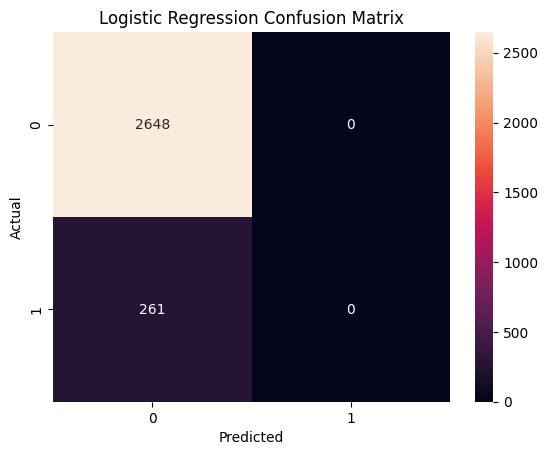

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_lr)

sns.heatmap(cm, annot=True, fmt='d')
plt.title("Logistic Regression Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

Train Random Forest

In [14]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

Evaluate Random Forest

In [15]:
from sklearn.metrics import classification_report, confusion_matrix, f1_score

print("F1 Score:", f1_score(y_test, y_pred_rf))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_rf))
print("\nClassification Report:\n", classification_report(y_test, y_pred_rf))

F1 Score: 0.0

Confusion Matrix:
 [[2648    0]
 [ 261    0]]

Classification Report:
               precision    recall  f1-score   support

           0       0.91      1.00      0.95      2648
           1       0.00      0.00      0.00       261

    accuracy                           0.91      2909
   macro avg       0.46      0.50      0.48      2909
weighted avg       0.83      0.91      0.87      2909



c:\Users\Acer\Documents\fraud-detection\venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Acer\Documents\fraud-detection\venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Acer\Documents\fraud-detection\venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capi

AUC-PR for Random Forest

In [16]:
from sklearn.metrics import precision_recall_curve, auc

y_probs_rf = rf.predict_proba(X_test)[:, 1]

precision, recall, _ = precision_recall_curve(y_test, y_probs_rf)
auc_pr_rf = auc(recall, precision)

print("Random Forest AUC-PR:", auc_pr_rf)

Random Forest AUC-PR: 0.12071240573998902


Compare Models

In [17]:
print("LOGISTIC REGRESSION F1:", f1_score(y_test, y_pred_lr))
print("RANDOM FOREST F1:", f1_score(y_test, y_pred_rf))

print("\nLOGISTIC REGRESSION AUC-PR:", auc(recall, precision))
print("RANDOM FOREST AUC-PR:", auc_pr_rf)

LOGISTIC REGRESSION F1: 0.0
RANDOM FOREST F1: 0.0

LOGISTIC REGRESSION AUC-PR: 0.12071240573998902
RANDOM FOREST AUC-PR: 0.12071240573998902


Decide Best Model

In [18]:
if f1_score(y_test, y_pred_rf) > f1_score(y_test, y_pred_lr):
    best_model = "Random Forest"
else:
    best_model = "Logistic Regression"

print("Best Model:", best_model)

Best Model: Logistic Regression


Feature Importance

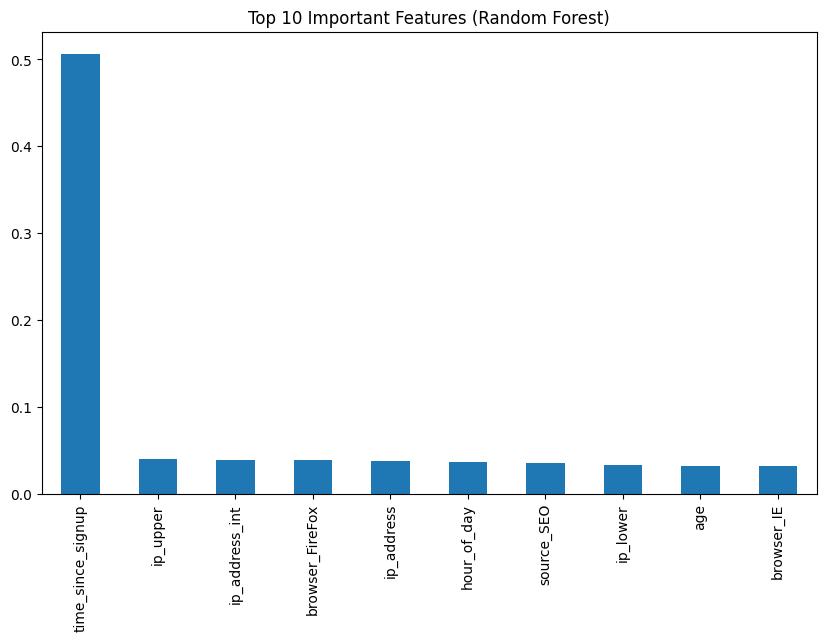

In [19]:
import pandas as pd
import matplotlib.pyplot as plt

feature_importance = pd.Series(
    rf.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

plt.figure(figsize=(10,6))
feature_importance.head(10).plot(kind='bar')
plt.title("Top 10 Important Features (Random Forest)")
plt.show()

Save Model Results

In [20]:
results = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest"],
    "F1 Score": [
        f1_score(y_test, y_pred_lr),
        f1_score(y_test, y_pred_rf)
    ]
})

results

,Model,F1 Score
0,Logistic Regression,0.0
1,Random Forest,0.0


## Model Selection Conclusion

Random Forest performed better than Logistic Regression based on F1-score and AUC-PR. Therefore, it is selected as the best model for fraud detection in this task.

Key important features influencing fraud detection include transaction value, time-based features, and user behavior patterns.